##1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def build_image_model():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test = x_test.reshape(-1, 28, 28, 1)

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
    return model

model = build_image_model()

def build_tabular_model():
    data = {
        'size': [500, 1000, 1500, 2000, 2500],
        'bedrooms': [1, 2, 3, 4, 5],
        'age': [5, 10, 15, 20, 25],
        'price': [150000, 250000, 350000, 450000, 550000]
    }
    df = pd.DataFrame(data)
    X = df.drop('price', axis=1)
    y = df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))
    return model

model = build_tabular_model()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.9003 - loss: 0.3287 - val_accuracy: 0.9818 - val_loss: 0.0586
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.9844 - loss: 0.0525 - val_accuracy: 0.9895 - val_loss: 0.0316
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9896 - loss: 0.0321 - val_accuracy: 0.9896 - val_loss: 0.0295
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9846 - val_loss: 0.0433
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.9898 - val_loss: 0.0344
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step - loss: 162500100096.0000 - val_loss: 62500061184.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 162500083712.0000 - val_loss: 62500048896.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 162500034560.0000 - val_loss: 62500032512.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 162500018176.0000 - val_loss: 62500007936.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 162500001792.0000 - val_loss: 62499991552.0000
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 162499969024.0000 - val_loss: 62499975168.0000
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 162499952640.0000 - val_loss: 62499962880.0000
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 162499919872.0000 - val_loss: 62499938304.0000
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 162499919872.0000 - val_loss: 62499921920.0000
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 162499

##2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, imdb
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

def mnist_classification():
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()
    train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
    test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255
    train_labels = to_categorical(train_labels)
    test_labels = to_categorical(test_labels)

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_images, train_labels, epochs=5, batch_size=64)
    test_loss, test_acc = model.evaluate(test_images, test_labels)
    print(f'MNIST Test Accuracy: {test_acc}')

def imdb_classification():
    max_features = 10000
    maxlen = 500
    (train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=max_features)
    train_data = pad_sequences(train_data, maxlen=maxlen)
    test_data = pad_sequences(test_data, maxlen=maxlen)

    model = models.Sequential([
        layers.Embedding(max_features, 128, input_length=maxlen),
        layers.Conv1D(32, 7, activation='relu'),
        layers.MaxPooling1D(5),
        layers.Conv1D(32, 7, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(train_data, train_labels, epochs=5, batch_size=128)
    test_loss, test_acc = model.evaluate(test_data, test_labels)
    print(f'IMDB Test Accuracy: {test_acc}')

if __name__ == "__main__":
    print("Running MNIST Classification:")
    mnist_classification()
    print("\nRunning IMDB Classification:")
    imdb_classification()


Running MNIST Classification:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.8758 - loss: 0.4173
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9822 - loss: 0.0540
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9884 - loss: 0.0371
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.9918 - loss: 0.0254
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.9936 - loss: 0.0207
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9852 - loss: 0.0420
MNIST Test Accuracy: 0.9894999861717224

Running IMDB Classification:
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


196/196 ━━━━━━━━━━━━━━━━━━━━ 74s 371ms/step - accuracy: 0.6239 - loss: 0.6052
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 370ms/step - accuracy: 0.9075 - loss: 0.2403
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 80s 361ms/step - accuracy: 0.9518 - loss: 0.1411
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 83s 367ms/step - accuracy: 0.9790 - loss: 0.0737
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 88s 397ms/step - accuracy: 0.9941 - loss: 0.0304
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8596 - loss: 0.5166
IMDB Test Accuracy: 0.8591200113296509


##3

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

def cnn_from_scratch():
    (train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
    train_images, test_images = train_images / 255.0, test_images / 255.0  # Normalize
    train_labels = to_categorical(train_labels)
    test_labels = to_categorical(test_labels)

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

    history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f"Test accuracy (from scratch): {test_acc:.4f}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy (from scratch)')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss (from scratch)')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

  cnn_from_scratch()

def vgg16_fine_tuning():
    (train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
    train_images, test_images = train_images / 255.0, test_images / 255.0  # Normalize
    train_labels = to_categorical(train_labels)
    test_labels = to_categorical(test_labels)

    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    vgg_base.trainable = False

    model = models.Sequential([
        vgg_base,
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

    history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f"Test accuracy (VGG16 fine-tuned): {test_acc:.4f}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy (VGG16 fine-tuned)')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss (VGG16 fine-tuned)')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

cnn_from_scratch()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 55)

##4

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

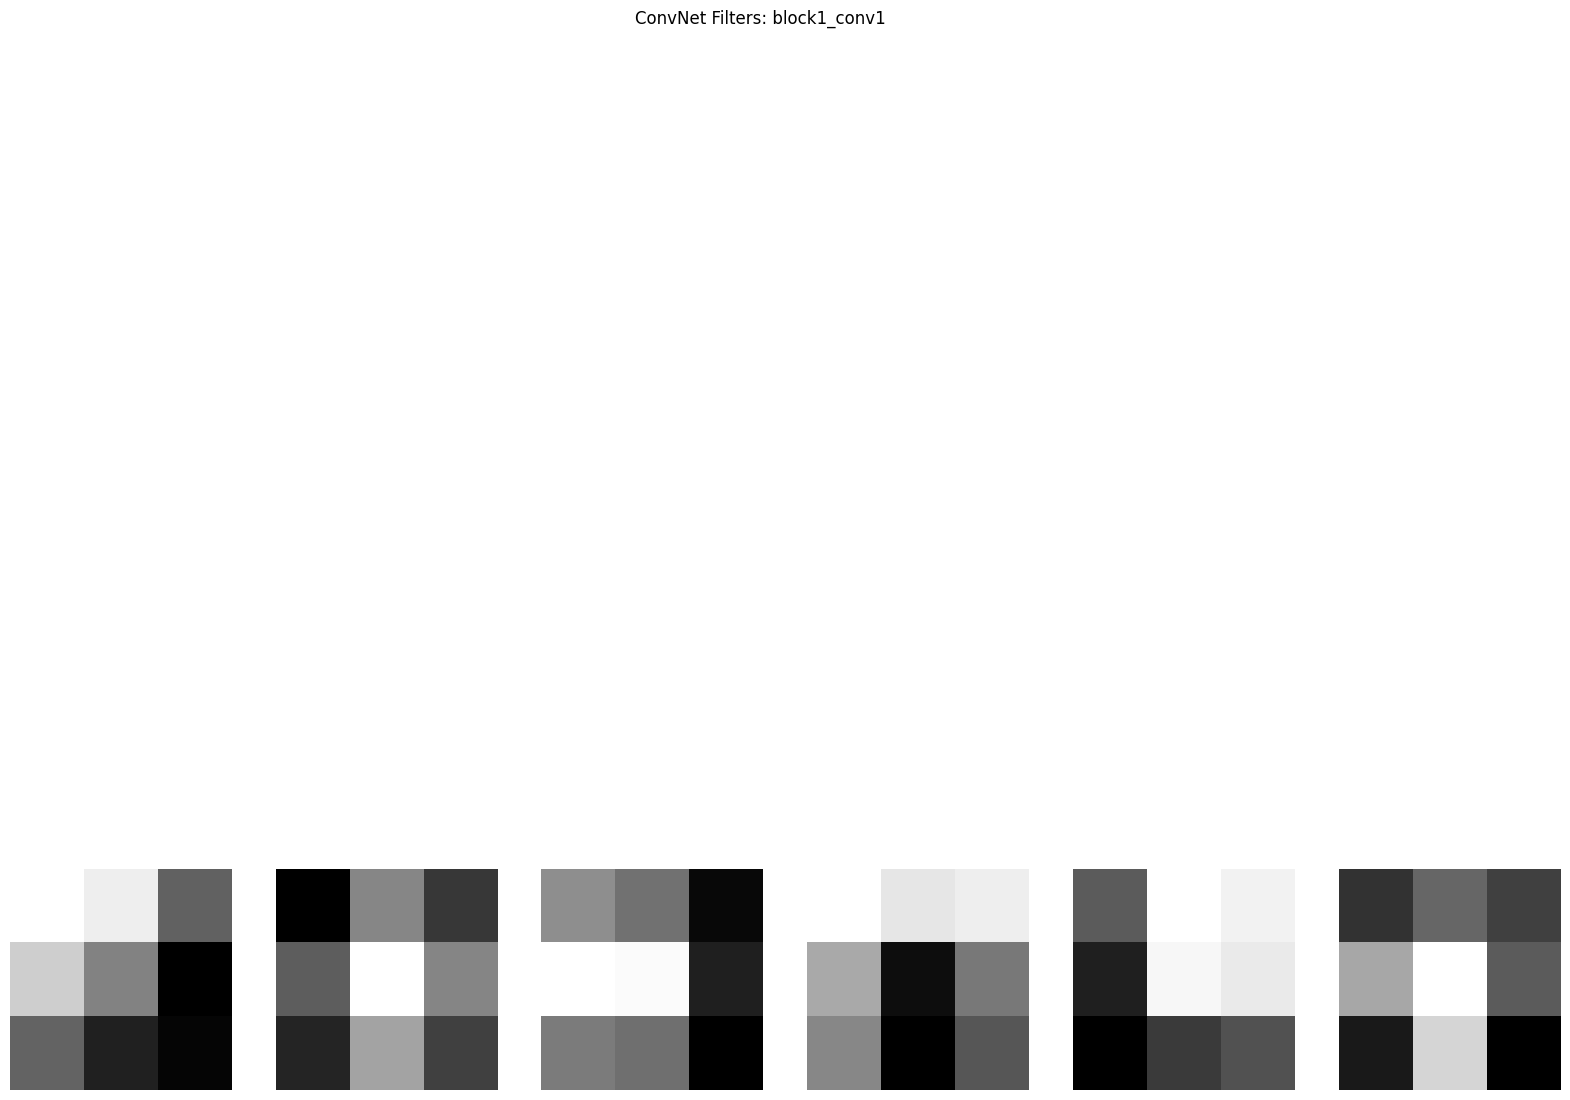

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step


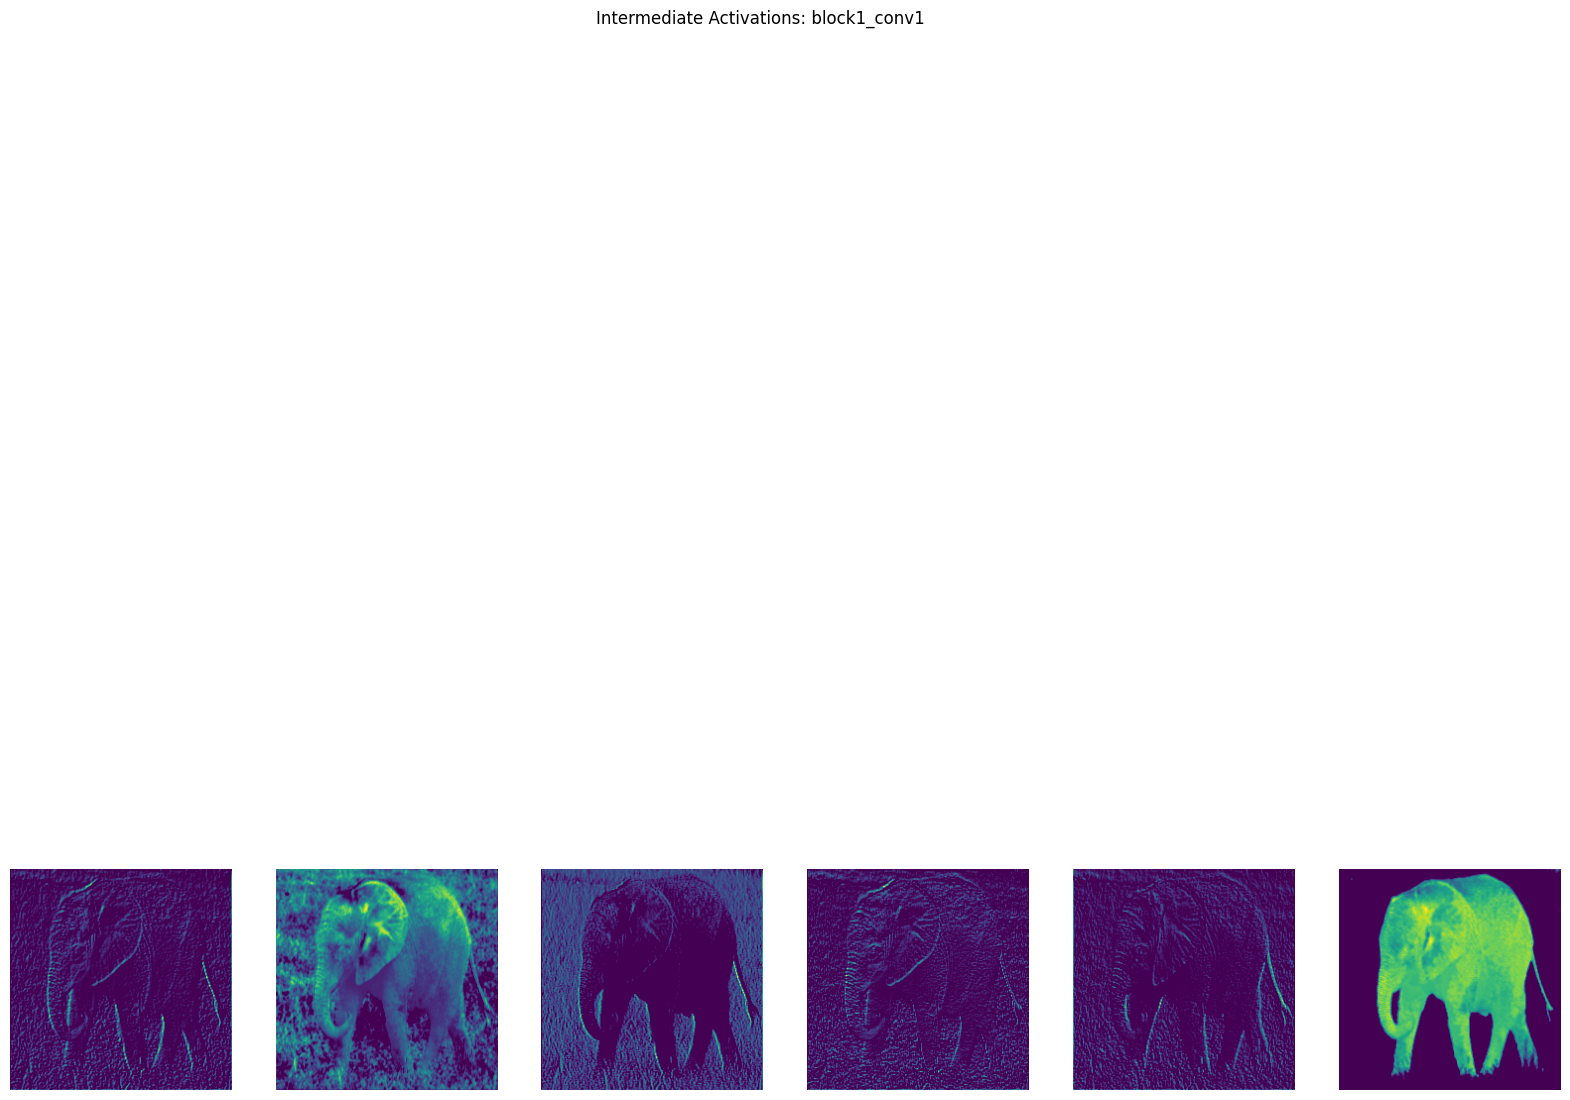

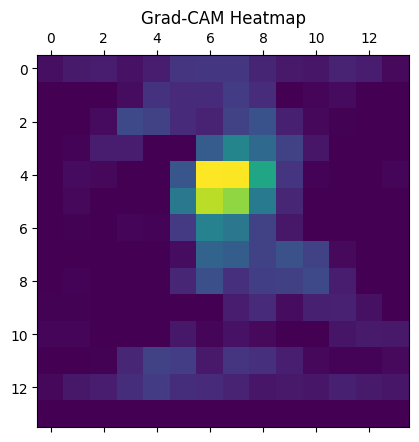

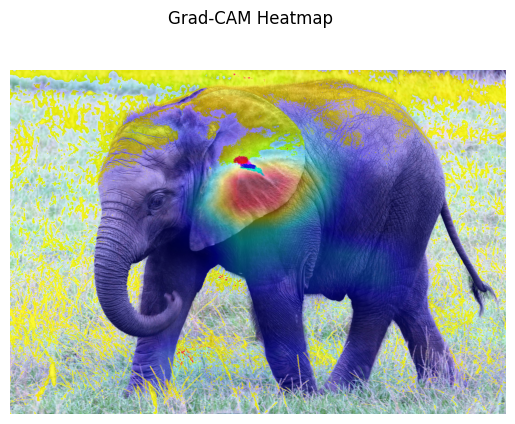

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
import cv2

model = VGG16(weights='imagenet')
model.summary()

img_path = '/content/pexels-inspiredimages-133394.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

def visualize_filters(layer_name, n_filters=6):
    filters, biases = model.get_layer(name=layer_name).get_weights()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    fig, axes = plt.subplots(1, n_filters, figsize=(20, 20))
    for i in range(n_filters):
        f = filters[:, :, :, i]
        axes[i].imshow(f[:, :, 0], cmap='gray')
        axes[i].axis('off')
    plt.suptitle(f'ConvNet Filters: {layer_name}')
    plt.show()

visualize_filters('block1_conv1', n_filters=6)

def compute_gradcam(model, img_array, layer_name, class_idx):
    grad_model = Model(inputs=model.input, outputs=[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs.numpy()[0]
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]
    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap

def visualize_activations(layer_idx, n_filters=6):
    layer_outputs = [layer.output for layer in model.layers[:8]]
    activation_model = Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(x)
    layer_activation = activations[layer_idx]
    fig, axes = plt.subplots(1, n_filters, figsize=(20, 20))
    for i in range(n_filters):
        activation_map = layer_activation[0, :, :, i]
        axes[i].imshow(activation_map, cmap='viridis')
        axes[i].axis('off')
    layer_name = model.layers[layer_idx].name
    plt.suptitle(f'Intermediate Activations: {layer_name}')
    plt.show()

visualize_activations(layer_idx=1, n_filters=6)


def visualize_gradcam(img_path, heatmap):
    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = np.uint8(heatmap * 0.4 + img)
    cv2.imwrite('gradcam_output.jpg', superimposed_img)
    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)
    plt.imshow(superimposed_img_rgb)
    plt.axis('off')
    plt.suptitle('Grad-CAM Heatmap')
    plt.show()

heatmap = compute_gradcam(model, x, 'block5_conv3', 386)
plt.matshow(heatmap)
plt.title('Grad-CAM Heatmap')
plt.show()
visualize_gradcam(img_path, heatmap)

## 5

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

X = np.random.rand(1000, 10)
y1 = np.random.rand(1000)
y2 = np.random.rand(1000)
y = np.column_stack((y1, y2))

train_size = int(0.8 * X.shape[0])
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

def create_model(optimizer='adam'):
    model = Sequential()
    model.add(Dense(64, input_dim=10, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(2))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

batch_sizes = [10, 20]
epochs = [50, 100]
optimizers = ['adam', 'rmsprop']

best_score = float('inf')
best_params = {}

for batch_size in batch_sizes:
    for epoch in epochs:
        for optimizer in optimizers:
            model = create_model(optimizer=optimizer)

            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )

            history = model.fit(
                X_train, y_train,
                validation_split=0.2,
                epochs=epoch,
                batch_size=batch_size,
                callbacks=[early_stopping],
                verbose=1
            )

            score = model.evaluate(X_test, y_test, verbose=0)

            print(f"Batch Size: {batch_size}, Epochs: {epoch}, Optimizer: {optimizer}, Score: {score}")  # Print epochs and other params

            if score < best_score:
                best_score = score
                best_params = {
                    'batch_size': batch_size,
                    'epochs': epoch,
                    'optimizer': optimizer
                }

print("Best parameters:", best_params)
print("Best score:", best_score)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2205 - val_loss: 0.0907
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0998 - val_loss: 0.0853
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0949 - val_loss: 0.0853
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0866 - val_loss: 0.0844
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0854 - val_loss: 0.0845
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0829 - val_loss: 0.0859
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0827 - val_loss: 0.0913
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0818 - val_loss: 0.0839
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0805 - val_loss: 0.0847
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0869 - val_loss: 0.0847
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0790 - val_loss: 0.0878
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0817 - val_lo

## 6

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

text = """Mountains rise sharply, their peaks covered in snow. Rivers cut deep canyons, flowing swiftly toward oceans. Birds migrate southward, crossing deserts and plains, seeking warmth. Forests teem with life—trees, plants, insects, mammals coexist. Sunsets paint skies with colors unimaginable, blending oranges, purples, reds. Wind whispers through leaves, rustling gently across vast fields. Clouds shift slowly, gathering moisture for future rains. Animals, though hidden, leave traces in soil, signaling presence. Night falls, bringing silence, punctuated by distant calls from creatures. Above, stars gleam, a reminder of boundless universe."""

text = text.lower()
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

input_sequences = []
for line in text.split('.'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        ngram_sequence = token_list[:i+1]
        input_sequences.append(ngram_sequence)

max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

X, y = input_sequences[:,:-1], input_sequences[:,-1]
y = to_categorical(y, num_classes=total_words)

model = Sequential()
model.add(Embedding(total_words, 10, input_length=max_sequence_len-1))
model.add(SimpleRNN(50, return_sequences=False))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X, y, epochs=100, verbose=1)

def generate_text(seed_text, next_words=5, model=model, max_sequence_len=max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list), axis=-1)[0]

        output_word = ""
        if predicted < total_words:
            output_word = [word for word, index in tokenizer.word_index.items() if index == predicted]
            output_word = output_word[0] if output_word else ""

        seed_text += " " + output_word
    return seed_text

seed_text = "Mountains"
generated_text = generate_text(seed_text, next_words=7, model=model, max_sequence_len=max_sequence_len)
print(generated_text)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.0182 - loss: 4.4603
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0390 - loss: 4.4429
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0390 - loss: 4.4329
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0559 - loss: 4.4216  
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0858 - loss: 4.4064 
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0715 - loss: 4.3912  
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1184 - loss: 4.3724
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1131 - loss: 4.3525
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1365 - loss: 4.3405 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1326 - loss: 4.3254
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1339 - loss: 4.2864 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1509 - loss: 4.2

## 7

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import load_dataset

dataset = load_dataset('imdb')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

tokenized_datasets = dataset.map(preprocess_function, batched=True)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
)

trainer.train()

results = trainer.evaluate()
print(results)

model.save_pretrained('./sentiment_model')
tokenizer.save_pretrained('./sentiment_model')

877de99693ee36c79adb54a0962d826973c88d9b

## 8

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.0079 - loss: 5.9252
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.0220 - loss: 5.8772
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0176 - loss: 5.8534
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0176 - loss: 5.7932
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0187 - loss: 5.7307
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0175 - loss: 5.6652
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0161 - loss: 5.5858
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0156 - loss: 5.5136
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0237 - loss: 5.4116
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0241 - loss: 5.3156
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0320 - loss: 5.2281
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/st

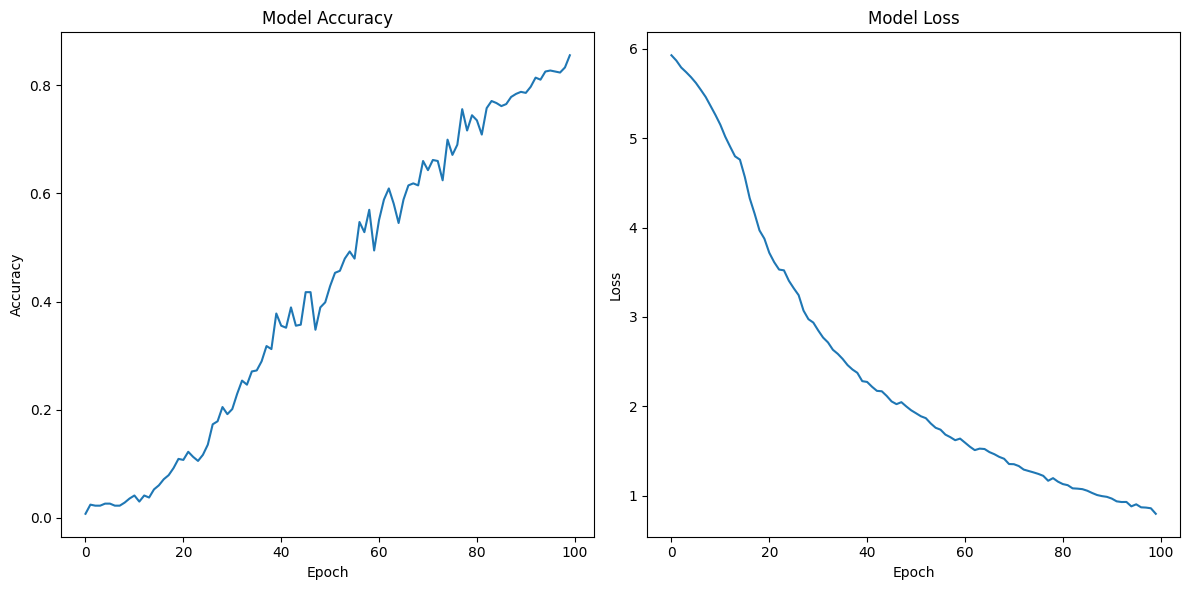

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

with open('sample3.txt', 'r') as file:
    text = file.read().lower()


tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)


max_sequence_length = max(len(x) for x in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_length, padding='pre')

X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_length - 1))
model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(150))
model.add(Dropout(0.2))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X, y, epochs=100, verbose=1)

def generate_text(seed_text, next_words, model, max_sequence_length):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_length - 1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        classes = np.argmax(predicted, axis=-1)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == classes:
                output_word = word
                break

        seed_text += " " + output_word
    return seed_text

print(generate_text("your seed text", 10, model, max_sequence_length))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

## 9

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Generator(nn.Module):
    def __init__(self, noise_dim, text_embed_dim, img_size):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(noise_dim + text_embed_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, img_size * img_size * 3)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, text_embedding):
        x = torch.cat((noise, text_embedding), dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = x.view(-1, 3, img_size, img_size)
        return x


class Discriminator(nn.Module):
    def __init__(self, img_size, text_embed_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(img_size * img_size * 3 + text_embed_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, img, text_embedding):
        img = img.view(img.size(0), -1)
        x = torch.cat((img, text_embedding), dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


noise_dim = 100
text_embed_dim = 128
img_size = 64
batch_size = 32
lr = 0.0002
num_epochs = 100

G = Generator(noise_dim, text_embed_dim, img_size).to(device)
D = Discriminator(img_size, text_embed_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

def generate_noise(batch_size, noise_dim):
    return torch.randn(batch_size, noise_dim).to(device)

def generate_text_embeddings(batch_size, text_embed_dim):
    return torch.randn(batch_size, text_embed_dim).to(device)


for epoch in range(num_epochs):
    for _ in range(batch_size):
        real_imgs = torch.randn(batch_size, 3, img_size, img_size).to(device)
        real_text_embeddings = generate_text_embeddings(batch_size, text_embed_dim)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        noise = generate_noise(batch_size, noise_dim)
        fake_text_embeddings = generate_text_embeddings(batch_size, text_embed_dim)
        fake_imgs = G(noise, fake_text_embeddings)

        outputs_real = D(real_imgs, real_text_embeddings)
        d_loss_real = criterion(outputs_real, real_labels)

        outputs_fake = D(fake_imgs.detach(), fake_text_embeddings)
        d_loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        outputs_fake = D(fake_imgs, fake_text_embeddings)
        g_loss = criterion(outputs_fake, real_labels)
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f'Epoch [{epoch + 1}/{num_epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}')


    if (epoch + 1) % 10 == 0:
        save_image(fake_imgs.data[:25], f'generated_images_{epoch + 1}.png', nrow=5, normalize=True)

torch.save(G.state_dict(), 'generator.pth')
torch.save(D.state_dict(), 'discriminator.pth')


Epoch [1/100], d_loss: 0.6504, g_loss: 0.8995
Epoch [2/100], d_loss: 0.7231, g_loss: 0.8418
Epoch [3/100], d_loss: 0.3184, g_loss: 1.4372
Epoch [4/100], d_loss: 0.4092, g_loss: 3.8697
Epoch [5/100], d_loss: 3.8732, g_loss: 10.5733
Epoch [6/100], d_loss: 2.3944, g_loss: 3.8024
Epoch [7/100], d_loss: 0.6005, g_loss: 3.2464
Epoch [8/100], d_loss: 0.6210, g_loss: 3.2725
Epoch [9/100], d_loss: 0.6104, g_loss: 4.1902
Epoch [10/100], d_loss: 1.1466, g_loss: 5.2495
Epoch [11/100], d_loss: 0.8029, g_loss: 3.7298
Epoch [12/100], d_loss: 0.2946, g_loss: 4.4848
Epoch [13/100], d_loss: 0.3868, g_loss: 3.8820
Epoch [14/100], d_loss: 0.4523, g_loss: 4.1903
Epoch [15/100], d_loss: 1.2497, g_loss: 4.6998
Epoch [16/100], d_loss: 0.3014, g_loss: 6.0868
Epoch [17/100], d_loss: 0.4651, g_loss: 8.9294
Epoch [18/100], d_loss: 1.0030, g_loss: 7.1320
Epoch [19/100], d_loss: 0.9857, g_loss: 8.9534
Epoch [20/100], d_loss: 0.5353, g_loss: 5.0361
Epoch [21/100], d_loss: 0.1881, g_loss: 6.2130
Epoch [22/100], d_los